# Reranker analysis

Compares runs with the reranker on (label `reranker`, this folder's `runs/`) against
the baseline (label `baseline`, `../baseline/runs`), on both collections. The
question: does the reranker improve ranking, and at what cost?

The companion question — with the reranker on, does contextualization still
matter? — is handled in the contextualization experiment (`../contextualization`).

In [20]:
import sys
sys.path.insert(0, "../../notebooks")   # shared eval library

from pathlib import Path
from minerva_eval import load_all_results, get_run_summary, metrics_heatmap, gold_ranks
import pandas as pd
import matplotlib.pyplot as plt

ROOTS = [Path("runs"), Path("../baseline/runs")]
all_results = load_all_results(ROOTS)
print(f"{len(all_results)} results, {len({r.query_id for r in all_results})} queries, "
      f"labels: {sorted({r.label for r in all_results})}")

1008 results, 84 queries, labels: ['baseline', 'reranker']


## Run summary

One row per run folder: collection, timestamp, sweep matrix, query count.

In [21]:
get_run_summary(ROOTS)

,folder,collection,timestamp,top_k,candidate_pool_size,sweep,queries,rows
0,2026-08-27T09-45-07Z_wikipedia-v1,wikipedia-nollm,2026-08-27T09:45:07Z,50,100,"alpha=[0.3, 0.5, 0.7], reranker=[True]",84,252
1,2026-08-27T10-28-44Z_wikipedia-v1,wikipedia-qwen2-5,2026-08-27T10:28:44Z,50,100,"alpha=[0.3, 0.5, 0.7], reranker=[True]",84,252
2,2026-08-27T08-43-19Z_wikipedia-v1,wikipedia-nollm,2026-08-27T08:43:19Z,50,100,"alpha=[0.3, 0.5, 0.7], reranker=[False]",84,252
3,2026-08-27T08-45-52Z_wikipedia-v1,wikipedia-qwen2-5,2026-08-27T08:45:52Z,50,100,"alpha=[0.3, 0.5, 0.7], reranker=[False]",84,252


## Metrics view

Mean over queries, grouped by `(label, collection, alpha)`. Read a `reranker` block
across alphas: flat metrics mean the reranker absorbs the pool-composition
differences (the alpha-inversion). Read `reranker` vs `baseline` at matched
`(collection, alpha)`: the headline reranker effect.

In [22]:
metrics_heatmap(all_results, group_cols=("collection", "label", "alpha"))

## Gold rank movement — reranker on vs off

Three views per collection at a fixed alpha, all built on
`delta = reranker_rank − baseline_rank` (negative = reranker better; missing gold
maps to `top_k + 1`):

- **crossing table** — per cutoff k: queries the reranker *rescues into* top-k
  (baseline out, reranker in) vs *drops out of* it (baseline in, reranker out).
  This is the only movement `R@k` can see.
- **delta histogram** — the distribution of movement. Ties (`delta == 0`) are
  omitted from the plot and printed instead; the mass at ±1–2 is tie-breaking
  wobble near the top, the tails are the real effect.
- **dumbbell** — one row per mover (`|delta| >= 3`), arrow from baseline rank to
  reranker rank. The dashed line is the top-10 cutoff: red arrows crossing it
  rightwards are the regressions that dent R@10.

wikipedia-nollm  alpha=0.5  ties: 49 of 84


,rescued,dropped,in_both,out_both
k,,,,
5,3,1,77,3
10,2,3,79,0


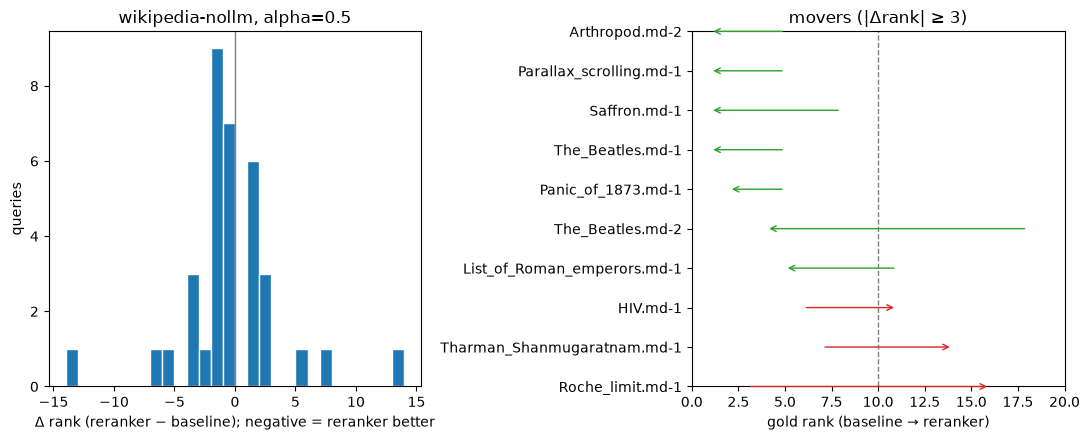

wikipedia-qwen2-5  alpha=0.5  ties: 43 of 84


,rescued,dropped,in_both,out_both
k,,,,
5,4,4,75,1
10,2,2,79,1


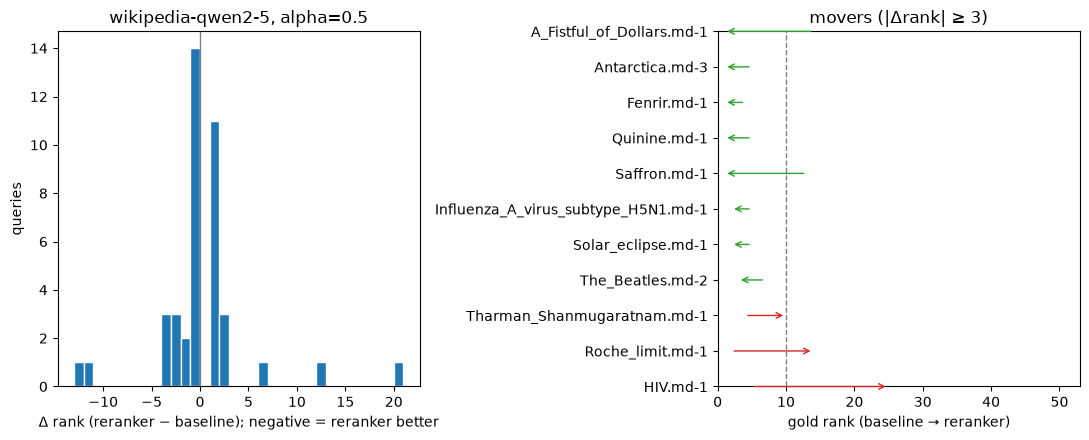

In [23]:
def gold_rank_per_query(results, alpha: float) -> pd.DataFrame:
    """Worst gold rank per (query, collection), one column per label, at a fixed alpha."""
    ranks = pd.DataFrame(vars(g) for g in gold_ranks(results))
    ranks = ranks[ranks["alpha"] == alpha]
    return ranks.pivot_table(index=["query_id", "collection"], columns="label",
                             values="rank", aggfunc="max")

ALPHA = 0.5
A, B = "baseline", "reranker"

cmp_all = gold_rank_per_query(all_results, ALPHA)
collections = sorted({r.collection for r in all_results})

def crossing_table(cmp: pd.DataFrame, ks=(5, 10)) -> pd.DataFrame:
    """Per cutoff k: paired top-k membership movement of the gold between the two labels."""
    rows = []
    for k in ks:
        rows.append({"k": k,
                     "rescued": ((cmp[A] > k) & (cmp[B] <= k)).sum(),
                     "dropped": ((cmp[A] <= k) & (cmp[B] > k)).sum(),
                     "in_both": ((cmp[A] <= k) & (cmp[B] <= k)).sum(),
                     "out_both": ((cmp[A] > k) & (cmp[B] > k)).sum()})
    return pd.DataFrame(rows).set_index("k")

def delta_histogram(delta: pd.Series, ax, title: str):
    moved = delta[delta != 0]
    ax.hist(moved, bins=range(int(moved.min()), int(moved.max()) + 2),
            color="tab:blue", edgecolor="white")
    ax.axvline(0, color="gray", lw=1)
    ax.set_xlabel(f"Δ rank ({B} − {A}); negative = {B} better")
    ax.set_ylabel("queries")
    ax.set_title(title)

def dumbbell(cmp: pd.DataFrame, ax, min_delta: int = 3, title: str = ""):
    movers = cmp[(cmp[B] - cmp[A]).abs() >= min_delta].sort_values(B)
    for y, (_, row) in enumerate(movers.iterrows()):
        improved = row[B] < row[A]
        ax.annotate("", xy=(row[B], y), xytext=(row[A], y),
                    arrowprops=dict(arrowstyle="->", color="tab:green" if improved else "tab:red"))
    ax.set_yticks(range(len(movers)))
    ax.set_yticklabels(movers.index)
    ax.axvline(10, ls="--", color="gray", lw=1)   # the R@10 cutoff
    ax.set_xlim(0, max(cmp[A].max(), cmp[B].max()) + 2)
    ax.set_xlabel(f"gold rank ({A} → {B})")
    ax.set_title(title)
    ax.invert_yaxis()

for collection in collections:
    cmp = cmp_all.xs(collection, level="collection")
    delta = cmp[B] - cmp[A]
    print(f"{collection}  alpha={ALPHA}  ties: {(delta == 0).sum()} of {len(delta)}")
    display(crossing_table(cmp))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
    delta_histogram(delta, ax1, f"{collection}, alpha={ALPHA}")
    dumbbell(cmp, ax2, title="movers (|Δrank| ≥ 3)")
    plt.tight_layout()
    plt.show()

## Effective headroom — who could move, and did it?

The raw better/worse counts understate the reranker because most queries sit at
the ceiling: the gold is already rank 1 under the baseline and can only hold or
wobble. Same data as above, but every count gets its proper denominator, per
collection at `ALPHA`:

- **at rank 1 / kept at 1** — the ceiling group, and how much of it the reranker
  preserves (the shortfall is the ±1 wobble visible in the histogram).
- **improvable** (baseline rank > 1) — split into improved / worsened / unchanged.
- **rescuable@k** (baseline rank > k) → **rescued@k**; **dropped@k** counts golds
  that were inside top-k and fell out. Rescued and dropped are the only movements
  `R@k` registers.

In [24]:
rows = []
for collection in collections:
    c = cmp_all.xs(collection, level="collection")
    d = c[B] - c[A]
    at1 = c[A] == 1
    row = {"collection": collection,
           "at rank 1": at1.sum(),
           "kept at 1": (at1 & (c[B] == 1)).sum(),
           "improvable": (~at1).sum(),
           "improved": (~at1 & (d < 0)).sum(),
           "worsened": (~at1 & (d > 0)).sum(),
           "unchanged": (~at1 & (d == 0)).sum()}
    for k in (5, 10):
        rescuable = c[A] > k
        row[f"rescuable@{k}"] = rescuable.sum()
        row[f"rescued@{k}"] = (rescuable & (c[B] <= k)).sum()
        row[f"dropped@{k}"] = (~rescuable & (c[B] > k)).sum()
    rows.append(row)

pd.DataFrame(rows).set_index("collection").T

collection,wikipedia-nollm,wikipedia-qwen2-5
at rank 1,49,51
kept at 1,42,41
improvable,35,33
improved,23,24
worsened,5,7
unchanged,7,2
rescuable@5,6,5
rescued@5,3,4
dropped@5,1,4
rescuable@10,2,3


## Latency

The reranker scores the full candidate pool (100 chunks per leg), so search is
expected to be much slower. Mean/median/max per-query latency per
`(label, collection, alpha)` quantifies the cost the quality gain has to justify.

In [25]:
lat = pd.DataFrame(
    {"label": r.label, "collection": r.collection,
     "alpha": r.cell.hybrid_alpha, "latency_ms": r.latency_ms}
    for r in all_results)
lat.groupby(["label", "collection", "alpha"])["latency_ms"].agg(["mean", "median", "max"]).round(0)

mean   median    max
label    collection        alpha                         
baseline wikipedia-nollm   0.3      582.0    572.0    798
                           0.5      578.0    570.0    771
                           0.7      647.0    625.0   1049
         wikipedia-qwen2-5 0.3      685.0    686.0    924
                           0.5      691.0    699.0    979
                           0.7      697.0    708.0    938
reranker wikipedia-nollm   0.3    10376.0  10330.0  13157
                           0.5    10373.0  10334.0  13240
                           0.7    10377.0  10300.0  13252
         wikipedia-qwen2-5 0.3    10691.0  10624.0  13810
                           0.5    12568.0  11532.0  18255
                           0.7    13954.0  14147.0  18366